# World Development Indicators Analysis

This notebook analyzes selected population and society indicators from the World Development Indicators dataset.

The analysis focuses on selected countries from the Middle East and North Africa (MENA) region.

### Main Areas
- Life Expectancy
- Lifetime Risk of Maternal Death
- Government Expenditure on Education
- Secondary School Enrollment

The same selected countries will be used throughout the analysis to ensure consistency across the project.

## 1. Load the Dataset

The dataset is downloaded from Kaggle and extracted into the Colab environment.

The main file used in this analysis is the SQLite database:
`database.sqlite`

In [1]:
#!pip install q kaggle
import os
os.environ['KAGGLE_CONFIG_DIR']='/content'

In [2]:
!kaggle datasets download -d kaggle/world-development-indicators

!unzip -q world-development-indicators.zip -d /content/world_development

Dataset URL: https://www.kaggle.com/datasets/kaggle/world-development-indicators
License(s): world-bank
100% 369M/369M [00:16<00:00, 23.1MB/s]



## 2. Import Required Libraries

The analysis uses:
- SQLite for querying the database
- Pandas for data analysis
- NumPy for numerical operations
- Matplotlib for visualization

In [3]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt


## 3. Connect to the SQLite Database

The World Development Indicators dataset is stored in a SQLite database.

We establish a connection to the database so that the required indicators can be extracted using SQL queries.

In [4]:
#database = "database.sqlite2\database.sqlite"
database = '/content/world_development/database.sqlite'
conn = sqlite3.connect(database)

## 4. Explore the Database Tables

Before starting the analysis, we inspect the available tables in the database.

This helps us understand the database structure and identify the tables needed for the analysis.

In [5]:
tables = pd.read_sql("""SELECT *
                         FROM sqlite_master
                        WHERE type='table';""", conn)
tables

,type,name,tbl_name,rootpage,sql
0,table,Country,Country,2,"CREATE TABLE Country (\n CountryCode TEXT,\..."
1,table,CountryNotes,CountryNotes,186,CREATE TABLE CountryNotes (\n Countrycode T...
2,table,Series,Series,948,"CREATE TABLE Series (\n SeriesCode TEXT,\n ..."
3,table,Indicators,Indicators,4448,CREATE TABLE Indicators (\n CountryName TEX...
4,table,SeriesNotes,SeriesNotes,1317550,CREATE TABLE SeriesNotes (\n Seriescode TEX...
5,table,Footnotes,Footnotes,1317587,CREATE TABLE Footnotes (\n Countrycode TEXT...


## 5. Explore MENA Indicators

The `Country` table contains information about countries and their regions, while the `Indicators` table contains the actual indicator observations.

A JOIN is used through `CountryCode` to retrieve indicators belonging to countries in the Middle East & North Africa region.

In [24]:
indicators_table = pd.read_sql("""
SELECT i.*
FROM Indicators i
JOIN Country c
    ON i.CountryCode = c.CountryCode
WHERE c.Region = 'Middle East & North Africa';
""", conn)

indicators_table

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
0,Algeria,DZA,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960,1.238892e+02
1,Algeria,DZA,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960,9.142517e+01
2,Algeria,DZA,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,1960,6.166136e+00
3,Algeria,DZA,"Age dependency ratio, young (% of working-age ...",SP.POP.DPND.YG,1960,8.525903e+01
4,Algeria,DZA,"Agriculture, value added (constant 2005 US$)",NV.AGR.TOTL.KD,1960,1.915338e+09
...,...,...,...,...,...,...
509569,"Yemen, Rep.",YEM,Time required to register property (days),IC.PRP.DURS,2015,1.900000e+01
509570,"Yemen, Rep.",YEM,Time required to start a business (days),IC.REG.DURS,2015,4.000000e+01
509571,"Yemen, Rep.",YEM,Time to prepare and pay taxes (hours),IC.TAX.DURS,2015,2.480000e+02
509572,"Yemen, Rep.",YEM,Time to resolve insolvency (years),IC.ISV.DURS,2015,3.000000e+00


## 6. Count MENA Countries

We count the distinct countries classified under the Middle East & North Africa region.

This provides an overview of the geographic scope available in the database.

In [25]:
count_of_countries = pd.read_sql("""
SELECT COUNT(DISTINCT CountryCode) AS Number_of_Countries
FROM Country
WHERE Region = 'Middle East & North Africa';
""", conn)

count_of_countries

,Number_of_Countries
0,21


## 7. MENA Country Information

The following query retrieves the country information for countries classified as part of the MENA region.

This table is used to understand the available countries before selecting the countries used consistently throughout the analysis.

In [26]:
country_table = pd.read_sql("""
SELECT *
FROM Country
WHERE Region = 'Middle East & North Africa';
""", conn)

country_table

,CountryCode,ShortName,TableName,LongName,Alpha2Code,CurrencyUnit,SpecialNotes,Region,IncomeGroup,Wb2Code,...,GovernmentAccountingConcept,ImfDataDisseminationStandard,LatestPopulationCensus,LatestHouseholdSurvey,SourceOfMostRecentIncomeAndExpenditureData,VitalRegistrationComplete,LatestAgriculturalCensus,LatestIndustrialData,LatestTradeData,LatestWaterWithdrawalData
0,DZA,Algeria,Algeria,People's Democratic Republic of Algeria,DZ,Algerian dinar,,Middle East & North Africa,Upper middle income,DZ,...,Budgetary central government,General Data Dissemination System (GDDS),2008,"Multiple Indicator Cluster Survey (MICS), 2012","Integrated household survey (IHS), 1995",,,2010,2013,2001
1,BHR,Bahrain,Bahrain,Kingdom of Bahrain,BH,Bahraini dinar,Based on official government statistics; the n...,Middle East & North Africa,High income: nonOECD,BH,...,Budgetary central government,General Data Dissemination System (GDDS),2010,,,Yes,,2010,2011,2003
2,DJI,Djibouti,Djibouti,Republic of Djibouti,DJ,Djibouti franc,,Middle East & North Africa,Lower middle income,DJ,...,,General Data Dissemination System (GDDS),2009,"Multiple Indicator Cluster Survey (MICS), 2006","Priority survey (PS), 2002",,,,2009,2000
3,EGY,Egypt,"Egypt, Arab Rep.",Arab Republic of Egypt,EG,Egyptian pound,Fiscal year end: June 30; reporting period for...,Middle East & North Africa,Lower middle income,EG,...,Consolidated central government,Special Data Dissemination Standard (SDDS),2006,"Demographic and Health Survey (DHS), 2014","Expenditure survey/budget survey (ES/BS), 2011",Yes,2009/2010,2010,2013,2000
4,IRN,Iran,"Iran, Islamic Rep.",Islamic Republic of Iran,IR,Iranian rial,Fiscal year end: March 20; reporting period fo...,Middle East & North Africa,Upper middle income,IR,...,Consolidated central government,General Data Dissemination System (GDDS),2011,Iran's Multiple Indicator Demographic and Heal...,"Expenditure survey/budget survey (ES/BS), 2005",Yes,2013,2010,2011,2004
5,IRQ,Iraq,Iraq,Republic of Iraq,IQ,Iraqi dinar,,Middle East & North Africa,Upper middle income,IQ,...,,General Data Dissemination System (GDDS),1997,"Multiple Indicator Cluster Survey (MICS), 2011","Integrated household survey (IHS), 2012",,2011/2012,2011,,2000
6,ISR,Israel,Israel,State of Israel,IL,Israeli new shekel,Based on official government statistics for ch...,Middle East & North Africa,High income: OECD,IL,...,Consolidated central government,Special Data Dissemination Standard (SDDS),2009,,"Expenditure survey/budget survey (ES/BS), 2010",Yes,,2010,2013,2004
7,JOR,Jordan,Jordan,Hashemite Kingdom of Jordan,JO,Jordanian dinar,,Middle East & North Africa,Upper middle income,JO,...,,Special Data Dissemination Standard (SDDS),2004,"Demographic and Health Survey (DHS), 2012","Expenditure survey/budget survey (ES/BS), 2010",,2007,2011,2013,2005
8,KWT,Kuwait,Kuwait,State of Kuwait,KW,Kuwaiti dinar,Fiscal year end: June 30; reporting period for...,Middle East & North Africa,High income: nonOECD,KW,...,Budgetary central government,General Data Dissemination System (GDDS),2011,"Family Health Survey (FHS), 1996",,Yes,,2011,2013,2002
9,LBN,Lebanon,Lebanon,Lebanese Republic,LB,Lebanese pound,,Middle East & North Africa,Upper middle income,LB,...,Budgetary central government,General Data Dissemination System (GDDS),1943,"Family Health Survey (FHS), 2004",,Yes,2011,2007,2013,2005


## 8. Data Selection

To maintain consistency across the project, the same selected countries will be used for all population and society analyses.

The selected countries are:

- Egypt
- Iran
- Iraq
- Libya
- Morocco
- Saudi Arabia
- Tunisia
- United Arab Emirates
- West Bank and Gaza
- Yemen
- Syrian Arab Republic

In [27]:
selected_country_codes = [
    'EGY',
    'IRN',
    'IRQ',
    'LBY',
    'MAR',
    'SAU',
    'TUN',
    'ARE',
    'WBG',
    'YEM',
    'SYR'
]

## 9. Life Expectancy

Life expectancy at birth is analyzed over time for the selected countries.

The analysis uses the indicator:

**Life expectancy at birth, total (years)**

Using `CountryCode` ensures that the same selected countries are consistently used.

In [28]:
life_expectancy_countries = pd.read_sql("""
SELECT *
FROM Indicators
WHERE CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)
AND IndicatorName = 'Life expectancy at birth, total (years)'
ORDER BY CountryName, Year
""", conn)

life_expectancy_countries

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
0,"Egypt, Arab Rep.",EGY,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,48.013707
1,"Egypt, Arab Rep.",EGY,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1961,48.581585
2,"Egypt, Arab Rep.",EGY,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1962,49.106512
3,"Egypt, Arab Rep.",EGY,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1963,49.601951
4,"Egypt, Arab Rep.",EGY,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1964,50.075390
...,...,...,...,...,...,...
559,"Yemen, Rep.",YEM,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2009,62.485341
560,"Yemen, Rep.",YEM,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2010,62.768732
561,"Yemen, Rep.",YEM,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2011,63.053537
562,"Yemen, Rep.",YEM,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2012,63.327293


### Life Expectancy Over Time

The line chart shows how life expectancy changed over time across the selected countries.

Five countries are highlighted to make the comparison easier to read, while the remaining countries are displayed with lighter lines.

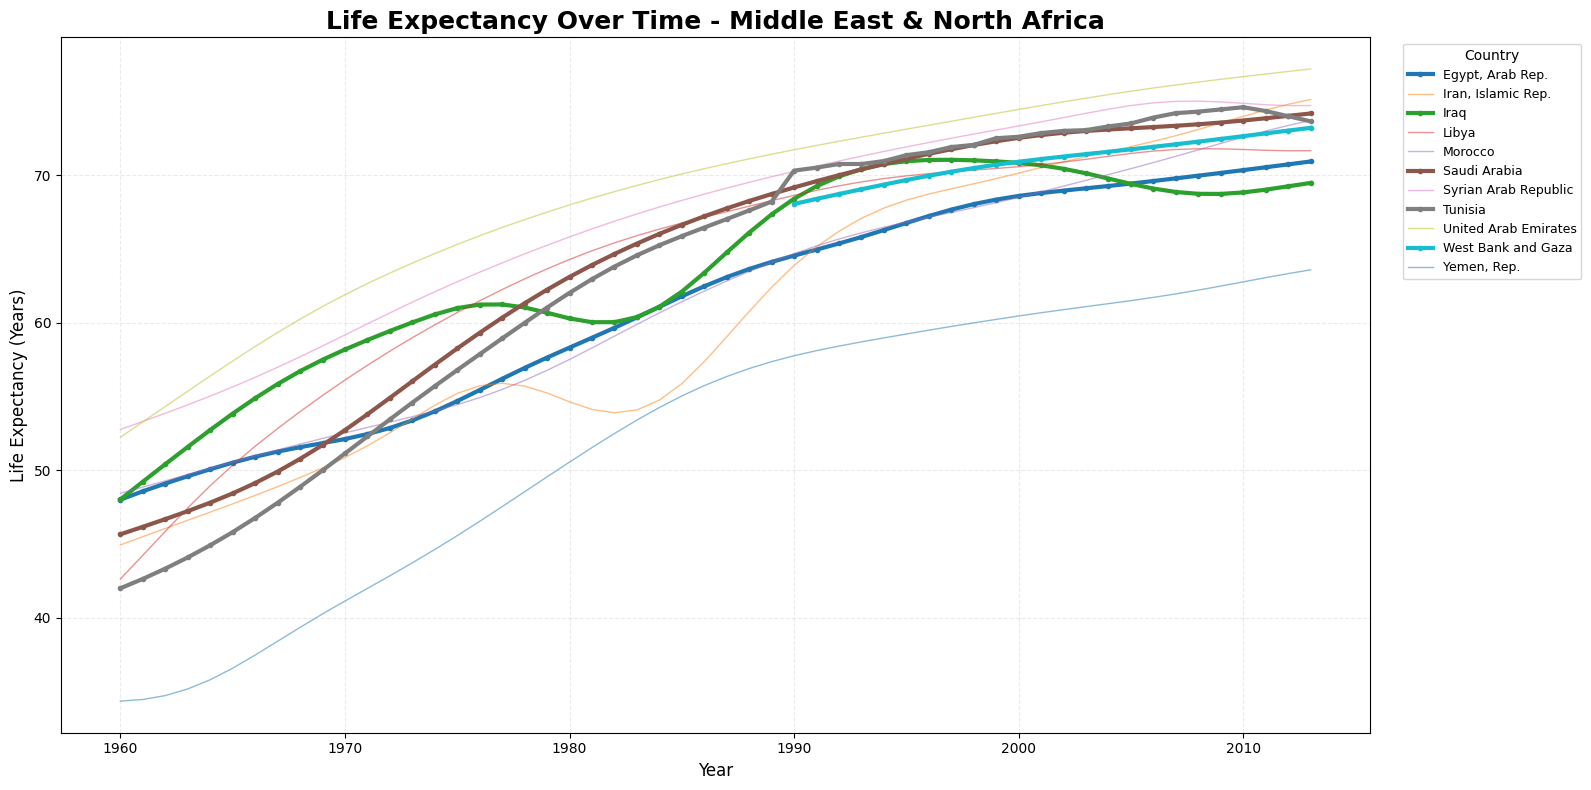

In [29]:
plt.figure(figsize=(16, 8))

highlighted = [
    'Egypt, Arab Rep.',
    'West Bank and Gaza',
    'Iraq',
    'Saudi Arabia',
    'Tunisia'
]

for country in life_expectancy_countries['CountryName'].unique():
    country_data = life_expectancy_countries[
        life_expectancy_countries['CountryName'] == country
    ]

    if country in highlighted:
        plt.plot(
            country_data['Year'],
            country_data['Value'],
            label=country,
            linewidth=3,
            marker='o',
            markersize=3
        )
    else:
        plt.plot(
            country_data['Year'],
            country_data['Value'],
            label=country,
            linewidth=1,
            alpha=0.5
        )

plt.title(
    'Life Expectancy Over Time - Middle East & North Africa',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Life Expectancy (Years)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.25)

plt.legend(
    title='Country',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=9
)

plt.tight_layout()
plt.show()

## 10. Lifetime Risk of Maternal Death

This section analyzes the lifetime risk of maternal death over time for the same selected countries.

The indicator used is:

**Lifetime risk of maternal death (%)**

This is treated as an additional population and health-related analysis.

In [30]:
lifetime_risk_of_maternal_death = pd.read_sql("""
SELECT *
FROM Indicators
WHERE CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)
AND IndicatorName = 'Lifetime risk of maternal death (%)'
ORDER BY CountryName, Year
""", conn)

lifetime_risk_of_maternal_death

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
0,"Egypt, Arab Rep.",EGY,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,1990,0.533855
1,"Egypt, Arab Rep.",EGY,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,1991,0.490358
2,"Egypt, Arab Rep.",EGY,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,1992,0.446968
3,"Egypt, Arab Rep.",EGY,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,1993,0.404746
4,"Egypt, Arab Rep.",EGY,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,1994,0.366605
...,...,...,...,...,...,...
281,"Yemen, Rep.",YEM,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,2011,1.944576
282,"Yemen, Rep.",YEM,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,2012,1.887216
283,"Yemen, Rep.",YEM,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,2013,1.829425
284,"Yemen, Rep.",YEM,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,2014,1.752392


### Lifetime Risk of Maternal Death Over Time

The following line chart compares changes in the lifetime risk of maternal death across the selected countries.

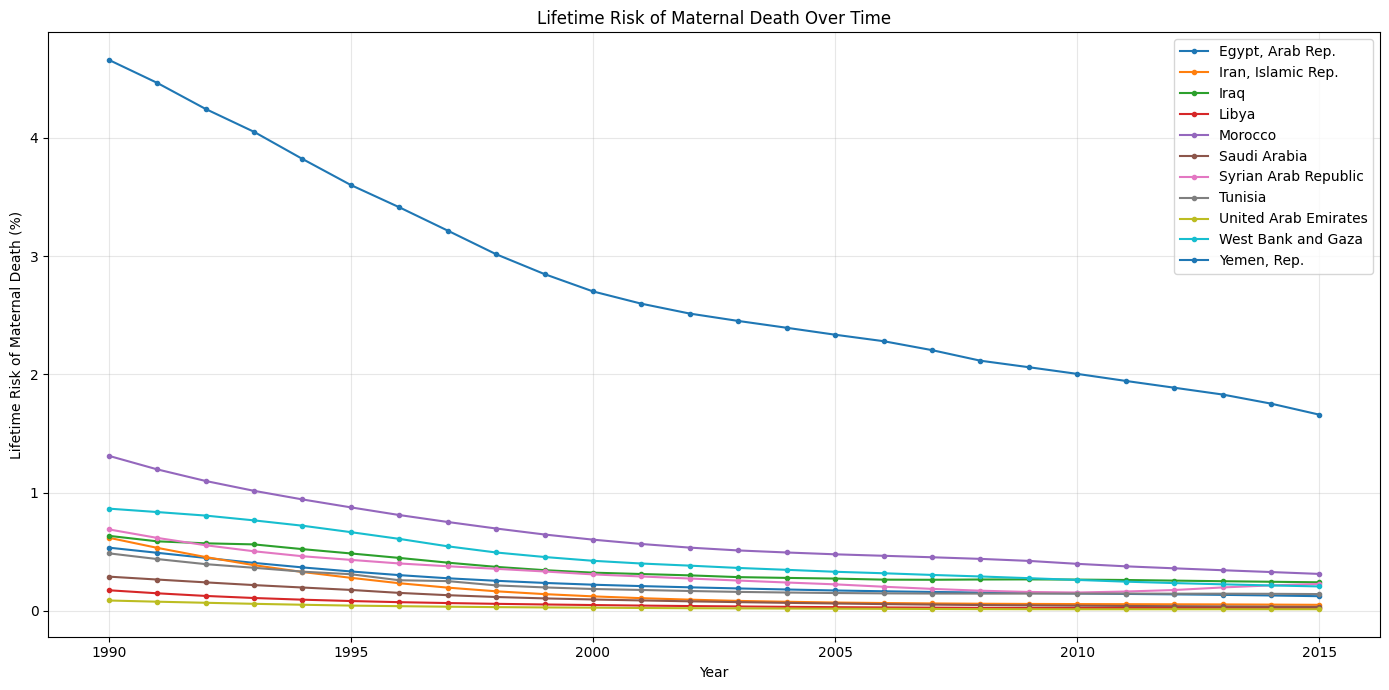

In [33]:
plt.figure(figsize=(14, 7))

for country in lifetime_risk_of_maternal_death['CountryName'].unique():
    country_data = lifetime_risk_of_maternal_death[
        lifetime_risk_of_maternal_death['CountryName'] == country
    ]

    plt.plot(
        country_data['Year'],
        country_data['Value'],
        label=country,
        marker='o',
        markersize=3
    )

plt.title('Lifetime Risk of Maternal Death Over Time')
plt.xlabel('Year')
plt.ylabel('Lifetime Risk of Maternal Death (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 11. Education Indicators

Education is analyzed using two indicators:

1. Government Expenditure on Education (% of GDP)
2. Secondary School Enrollment (% gross)

First, we inspect the available government education expenditure indicators in the database.

In [34]:
education_indicators = pd.read_sql("""
SELECT DISTINCT IndicatorName, IndicatorCode
FROM Indicators
WHERE CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)
AND IndicatorName LIKE 'Government expenditure on education%'
""", conn)

education_indicators

,IndicatorName,IndicatorCode
0,Government expenditure on education as % of GD...,SE.XPD.TOTL.GD.ZS


## 12. Government Expenditure on Education

The selected indicator is:

**Government expenditure on education, total (% of GDP)**

The analysis examines how government education expenditure changed over time across the selected countries.

In [35]:
education = pd.read_sql("""
SELECT CountryName, Year, Value
FROM Indicators
WHERE CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)
AND IndicatorCode = 'SE.XPD.TOTL.GD.ZS'
ORDER BY CountryName, Year
""", conn)

education

,CountryName,Year,Value
0,"Egypt, Arab Rep.",1971,4.74202
1,"Egypt, Arab Rep.",1972,4.72636
2,"Egypt, Arab Rep.",1974,5.48853
3,"Egypt, Arab Rep.",1975,5.00846
4,"Egypt, Arab Rep.",1976,5.02737
...,...,...,...
172,Tunisia,2012,6.22349
173,United Arab Emirates,1997,1.10944
174,"Yemen, Rep.",2000,9.66163
175,"Yemen, Rep.",2001,9.24471


### Handling Missing Values

For the following analysis, observations with missing values are excluded.

The original dataset may contain years where an indicator is not available for a country, so missing values are considered as part of the data quality assessment rather than being treated as zero.

In [36]:
education_expenditure = pd.read_sql("""
SELECT CountryName, Year, Value
FROM Indicators
WHERE CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)
AND IndicatorCode = 'SE.XPD.TOTL.GD.ZS'
AND Value IS NOT NULL
ORDER BY CountryName, Year
""", conn)

education_expenditure

,CountryName,Year,Value
0,"Egypt, Arab Rep.",1971,4.74202
1,"Egypt, Arab Rep.",1972,4.72636
2,"Egypt, Arab Rep.",1974,5.48853
3,"Egypt, Arab Rep.",1975,5.00846
4,"Egypt, Arab Rep.",1976,5.02737
...,...,...,...
172,Tunisia,2012,6.22349
173,United Arab Emirates,1997,1.10944
174,"Yemen, Rep.",2000,9.66163
175,"Yemen, Rep.",2001,9.24471


### Government Expenditure on Education Over Time

The line chart illustrates changes in government expenditure on education as a percentage of GDP over time for the selected countries.

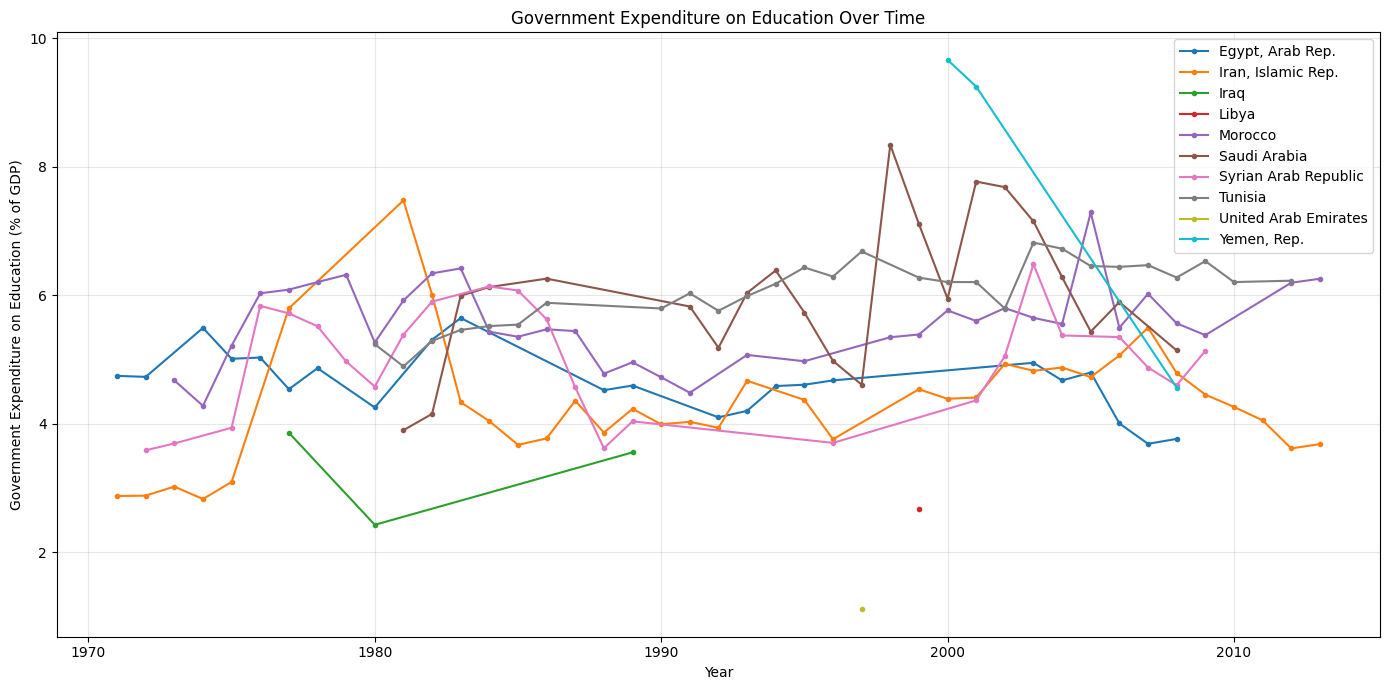

In [37]:
plt.figure(figsize=(14, 7))

for country in education_expenditure['CountryName'].unique():
    country_data = education_expenditure[
        education_expenditure['CountryName'] == country
    ]

    plt.plot(
        country_data['Year'],
        country_data['Value'],
        label=country,
        marker='o',
        markersize=3
    )

plt.title('Government Expenditure on Education Over Time')
plt.xlabel('Year')
plt.ylabel('Government Expenditure on Education (% of GDP)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Secondary School Enrollment

The second education indicator is:

**School enrollment, secondary (% gross)**

This indicator is used to examine secondary-level enrollment across the same selected countries.

In [38]:
secondary_students = pd.read_sql("""
SELECT CountryName, Year, Value
FROM Indicators
WHERE CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)
AND IndicatorCode = 'SE.SEC.ENRR'
AND Value IS NOT NULL
ORDER BY CountryName, Year
""", conn)

secondary_students

,CountryName,Year,Value
0,"Egypt, Arab Rep.",1971,30.408620
1,"Egypt, Arab Rep.",1972,31.698150
2,"Egypt, Arab Rep.",1973,32.805840
3,"Egypt, Arab Rep.",1974,33.784880
4,"Egypt, Arab Rep.",1975,36.551380
...,...,...,...
296,"Yemen, Rep.",2008,43.401440
297,"Yemen, Rep.",2010,44.304218
298,"Yemen, Rep.",2011,46.230572
299,"Yemen, Rep.",2012,46.863819


### Secondary School Enrollment Over Time

The following line chart shows the changes in secondary school enrollment over time across the selected countries.

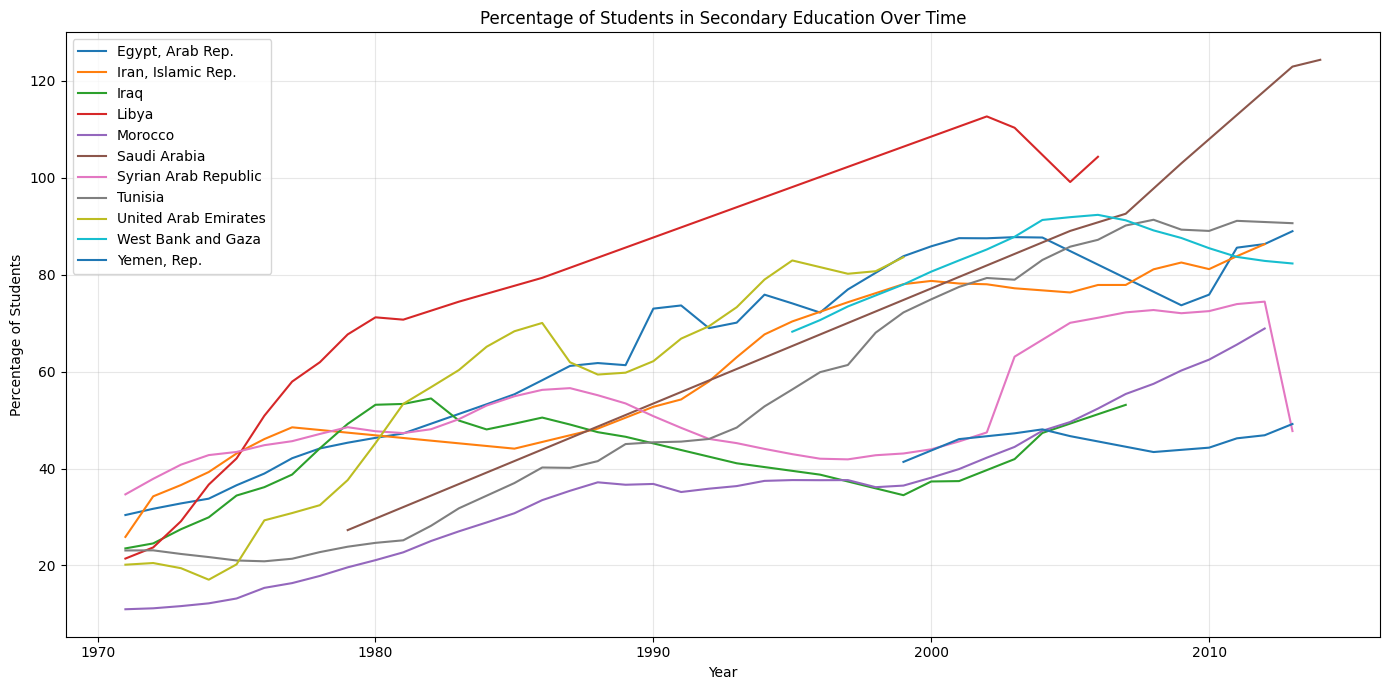

In [39]:
plt.figure(figsize=(14, 7))

for country in secondary_students['CountryName'].unique():
    country_data = secondary_students[
        secondary_students['CountryName'] == country
    ].sort_values('Year')

    plt.plot(
        country_data['Year'],
        country_data['Value'],
        label=country
    )

plt.title('Percentage of Students in Secondary Education Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage of Students')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Average Government Education Expenditure

To provide a simple country-level comparison, the mean government expenditure on education is calculated from the available observations for each country.

This is a descriptive average and does not imply a causal relationship with education outcomes.

In [40]:
avg_spending = education_expenditure.groupby('CountryName')['Value'].mean()
avg_spending

,Value
CountryName,
"Egypt, Arab Rep.",4.639459
"Iran, Islamic Rep.",4.305761
Iraq,3.277447
Libya,2.672040
Morocco,5.560857
Saudi Arabia,5.993614
Syrian Arab Republic,4.961290
Tunisia,6.054254
United Arab Emirates,1.109440


## 15. Average Secondary School Enrollment

The mean secondary school enrollment is calculated for each selected country using the available observations.

Missing observations are excluded from the mean calculation.

In [41]:
avg_students = secondary_students.groupby('CountryName')['Value'].mean()
avg_students

,Value
CountryName,
"Egypt, Arab Rep.",63.050012
"Iran, Islamic Rep.",63.994854
Iraq,42.275756
Libya,65.493407
Morocco,35.193960
Saudi Arabia,93.166677
Syrian Arab Republic,52.295984
Tunisia,52.677836
United Arab Emirates,53.774512


## 16. Education Indicators Comparison

The two country-level averages are combined into one table:

- Average Government Education Expenditure (% of GDP)
- Average Secondary School Enrollment (% gross)

The comparison is descriptive and is intended to show differences between the two indicators across countries.

In [42]:
comparison = pd.DataFrame({
    'Avg_Education_Spending': avg_spending,
    'Avg_Secondary_Students': avg_students
})
comparison.sort_values('Avg_Education_Spending', ascending=False)

,Avg_Education_Spending,Avg_Secondary_Students
CountryName,,
"Yemen, Rep.",7.822313,45.943414
Tunisia,6.054254,52.677836
Saudi Arabia,5.993614,93.166677
Morocco,5.560857,35.193960
Syrian Arab Republic,4.961290,52.295984
"Egypt, Arab Rep.",4.639459,63.050012
"Iran, Islamic Rep.",4.305761,63.994854
Iraq,3.277447,42.275756
Libya,2.672040,65.493407


### Education Spending vs Secondary School Enrollment

The following bar chart provides a direct visual comparison of the two average education-related indicators.

Because the two indicators have different meanings and different numerical ranges, the chart should be interpreted as a descriptive comparison rather than evidence of a causal relationship.

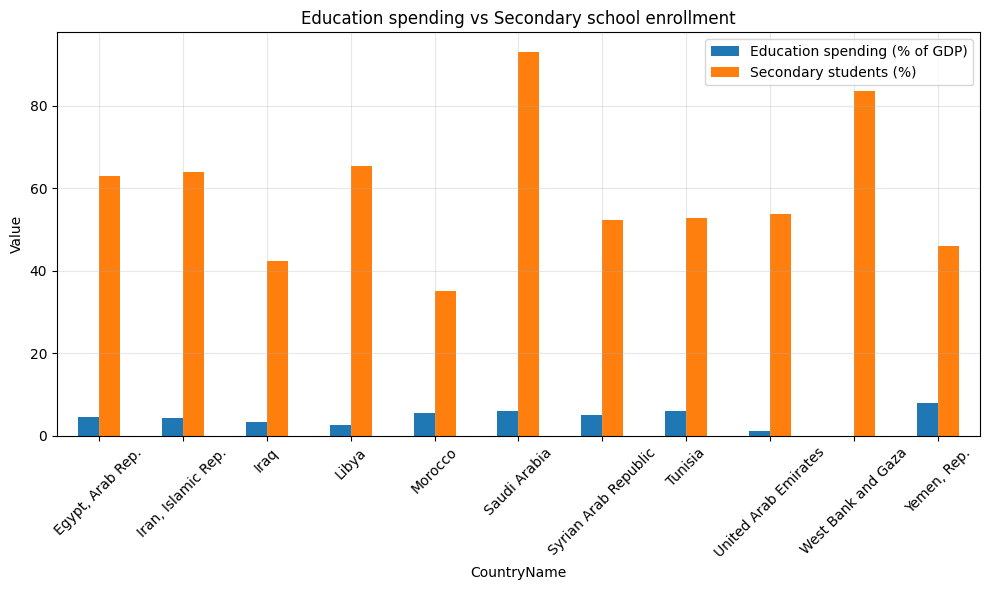

In [43]:
comparison.plot(kind='bar', figsize=(10,6))
plt.title('Education spending vs Secondary school enrollment')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend(['Education spending (% of GDP)', 'Secondary students (%)'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()